# Exam 01: Visual Solution Notebook

**Course:** Machine Learning Theory  
**Institution:** Universidad Nacional de Colombia  
**Term:** 2026-1  
**Student:** Martín RAmírez Espinosa

This notebook is designed to be shown directly. It solves the entire exam with derivations, code, plots, and visual explanations in one place.

The mathematical solution is complete through the derivation cells alone. The figures are supplementary: they illustrate and numerically verify the formulas, but the core argument does not depend on the visualizations.


## Setup

The auxiliary code below is used only for numerical verification of the derivations.


In [19]:
from __future__ import annotations

import gzip
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np


def find_mnist_data_dir() -> Path:
    """Locate the directory expected to contain the MNIST training gzip files.

    Search strategy:
    - start from the current working directory and walk through all parents
    - look for either `data/raw/mnist` or `mnist-data`

    Returns:
    - the first existing candidate when the dataset is already present
    - otherwise the preferred default path so later errors mention one concrete location
    """
    candidates = []
    for base in [Path.cwd().resolve(), *Path.cwd().resolve().parents]:
        candidates.append(base / "data" / "raw" / "mnist")
        candidates.append(base / "mnist-data")
    for candidate in candidates:
        if candidate.exists():
            return candidate
    return candidates[0]


MNIST_DATA_DIR = find_mnist_data_dir()


plt.rcParams.update({
    "figure.figsize": (10, 6),
    "axes.grid": True,
    "grid.alpha": 0.25,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "font.size": 11,
})


def build_polynomial_design_matrix(x_samples: np.ndarray) -> np.ndarray:
    """Build the Question 1 polynomial feature matrix `[1, x, x^2]`.

    The returned matrix has one row per sample and three columns corresponding to
    the bias, linear, and quadratic features used in the exam derivation.
    """
    x_vector = np.asarray(x_samples, dtype=np.float64).reshape(-1)
    return np.column_stack((np.ones_like(x_vector), x_vector, x_vector ** 2))


def solve_regularized_least_squares(
    design_matrix: np.ndarray,
    targets: np.ndarray,
    lambda_reg: float,
) -> np.ndarray:
    """Solve the primal ridge-regression system from Question 1.

    Parameters:
    - `design_matrix`: feature matrix `Phi`
    - `targets`: target vector `t`
    - `lambda_reg`: nonnegative Tikhonov regularization strength

    Returns:
    - the weight vector `w_hat = (Phi^T Phi + lambda I)^{-1} Phi^T t`
    """
    phi = np.asarray(design_matrix, dtype=np.float64)
    t = np.asarray(targets, dtype=np.float64).reshape(-1)
    gram = phi.T @ phi
    rhs = phi.T @ t
    system = gram + lambda_reg * np.eye(phi.shape[1], dtype=np.float64)
    return np.linalg.solve(system, rhs)


def solve_kernelized_regularized_least_squares(
    design_matrix: np.ndarray,
    targets: np.ndarray,
    lambda_reg: float,
):
    """Solve the dual ridge-regression system on the sample span.

    Returns a triple `(alpha, reconstructed_weights, kernel_matrix)` so the
    notebook can verify numerically that the primal solution and `Phi^T alpha`
    coincide up to machine precision.
    """
    phi = np.asarray(design_matrix, dtype=np.float64)
    t = np.asarray(targets, dtype=np.float64).reshape(-1)
    kernel_matrix = phi @ phi.T
    alpha = np.linalg.solve(kernel_matrix + lambda_reg * np.eye(phi.shape[0], dtype=np.float64), t)
    return alpha, phi.T @ alpha, kernel_matrix


def pairwise_squared_distances(x_matrix: np.ndarray) -> np.ndarray:
    """Compute the full squared Euclidean distance matrix for a sample set.

    The implementation uses the standard identity
    `||x_i - x_j||^2 = ||x_i||^2 + ||x_j||^2 - 2 <x_i, x_j>`
    so Questions 2 and 3 can reuse the same vectorized building block.
    """
    x = np.asarray(x_matrix, dtype=np.float64)
    squared_norms = np.sum(x * x, axis=1, keepdims=True)
    distances = squared_norms + squared_norms.T - 2.0 * (x @ x.T)
    return np.maximum(distances, 0.0)


def rbf_kernel_matrix(x_matrix: np.ndarray, gamma: float) -> np.ndarray:
    """Build the Gaussian Gram matrix `K_ij = exp(-gamma ||x_i - x_j||^2)` for one sample set."""
    return np.exp(-gamma * pairwise_squared_distances(x_matrix))


def cross_rbf_kernel_matrix(x_matrix: np.ndarray, y_matrix: np.ndarray, gamma: float) -> np.ndarray:
    """Build the Gaussian cross-kernel matrix between two sample sets."""
    x = np.asarray(x_matrix, dtype=np.float64)
    y = np.asarray(y_matrix, dtype=np.float64)
    x_norms = np.sum(x * x, axis=1, keepdims=True)
    y_norms = np.sum(y * y, axis=1, keepdims=True)
    distances = x_norms + y_norms.T - 2.0 * (x @ y.T)
    distances = np.maximum(distances, 0.0)
    return np.exp(-gamma * distances)


def biased_mmd2_from_gram(k_xx: np.ndarray, k_yy: np.ndarray, k_xy: np.ndarray) -> float:
    """Evaluate the biased empirical `MMD^2` formula directly from Gram matrices."""
    m = k_xx.shape[0]
    n = k_yy.shape[0]
    return float(np.sum(k_xx) / (m * m) + np.sum(k_yy) / (n * n) - 2.0 * np.sum(k_xy) / (m * n))


def median_heuristic_gamma(x_matrix: np.ndarray) -> float:
    """Choose the Gaussian kernel scale with the inverse median nonzero distance heuristic."""
    distances = pairwise_squared_distances(x_matrix)
    nonzero = distances[distances > 0.0]
    return float(1.0 / np.median(nonzero))


def require_mnist_file(filename: str) -> Path:
    """Return the path to one required MNIST gzip file or fail with a precise message."""
    path = MNIST_DATA_DIR / filename
    if path.exists():
        return path
    raise FileNotFoundError(
        f"Expected MNIST file {filename!r} under {MNIST_DATA_DIR}. "
        "This notebook assumes the MNIST training files are already available locally; "
        "without them the empirical visualizations in Questions 2.3 and 3 cannot be executed."
    )


def load_mnist_images(path: Path) -> np.ndarray:
    """Load normalized MNIST training images from the original IDX gzip container.

    Returns a matrix of shape `(count, 784)` scaled to `[0, 1]` so the later
    kernel computations operate directly on flattened grayscale vectors.
    """
    with gzip.open(path, "rb") as handle:
        magic = int.from_bytes(handle.read(4), "big")
        if magic != 2051:
            raise ValueError(f"Unexpected image magic number {magic}.")
        count = int.from_bytes(handle.read(4), "big")
        rows = int.from_bytes(handle.read(4), "big")
        cols = int.from_bytes(handle.read(4), "big")
        data = np.frombuffer(handle.read(), dtype=np.uint8)
    return data.reshape(count, rows * cols).astype(np.float64) / 255.0


def load_mnist_labels(path: Path) -> np.ndarray:
    """Load MNIST training labels from the original IDX gzip container."""
    with gzip.open(path, "rb") as handle:
        magic = int.from_bytes(handle.read(4), "big")
        if magic != 2049:
            raise ValueError(f"Unexpected label magic number {magic}.")
        count = int.from_bytes(handle.read(4), "big")
        data = np.frombuffer(handle.read(), dtype=np.uint8)
    return data.reshape(count)


def load_mnist_training_set():
    """Load the local MNIST training split used by the empirical Question 2 and 3 checks."""
    images = load_mnist_images(require_mnist_file("train-images-idx3-ubyte.gz"))
    labels = load_mnist_labels(require_mnist_file("train-labels-idx1-ubyte.gz"))
    return images, labels


def select_balanced_mnist_subset(
    images: np.ndarray,
    labels: np.ndarray,
    samples_per_class: int,
    seed: int,
):
    """Sample the same number of examples from each digit class.

    The result is a dictionary `digit -> image matrix`, which keeps the later MMD
    experiment aligned with the question wording: compare distributions class by class.
    """
    rng = np.random.default_rng(seed)
    by_digit = {}
    for digit in range(10):
        indices = np.flatnonzero(labels == digit)
        chosen = rng.choice(indices, size=samples_per_class, replace=False)
        by_digit[digit] = images[np.sort(chosen)]
    return by_digit


def polynomial_regression_example(lambda_reg: float):
    """Assemble all numerical artifacts used in the Question 1 visual summary.

    This helper keeps the execution cell compact by packaging the sample points,
    target values, primal solution, dual coefficients, predictions, and the feature-space
    Gram matrix in one dictionary.
    """
    x_samples = np.array([-2.0, -1.0, 0.0, 1.0, 2.0], dtype=np.float64)
    targets = 1.0 + 0.5 * x_samples + x_samples ** 2
    design_matrix = build_polynomial_design_matrix(x_samples)
    primal_weights = solve_regularized_least_squares(design_matrix, targets, lambda_reg=lambda_reg)
    alpha, dual_weights, kernel_matrix = solve_kernelized_regularized_least_squares(
        design_matrix,
        targets,
        lambda_reg=lambda_reg,
    )
    predictions = design_matrix @ primal_weights
    return {
        "x_samples": x_samples,
        "targets": targets,
        "design_matrix": design_matrix,
        "estimated_weights": primal_weights,
        "predictions": predictions,
        "alpha": alpha,
        "kernel_matrix": kernel_matrix,
        "max_abs_primal_dual_difference": float(np.max(np.abs(primal_weights - dual_weights))),
    }


def mean_embedding_demo():
    """Create the small finite-sample example used to explain empirical mean embeddings.

    The dictionary compares two equivalent linear evaluations and one nonlinear
    RBF evaluation at the same query point, making the RKHS idea concrete before
    moving to the full MMD experiment on MNIST.
    """
    x_samples = np.array([[0.0, 1.0], [1.0, 0.0], [2.0, 1.0]], dtype=np.float64)
    z_query = np.array([1.0, 2.0], dtype=np.float64)
    sample_mean = np.mean(x_samples, axis=0)
    linear_eval = float(sample_mean @ z_query)
    direct_linear_eval = float(np.mean(x_samples @ z_query))
    gamma = 0.5
    rbf_values = np.exp(-gamma * np.sum((x_samples - z_query) ** 2, axis=1))
    rbf_eval = float(np.mean(rbf_values))
    return {
        "samples": x_samples,
        "query": z_query,
        "linear_sample_mean": sample_mean,
        "linear_eval_via_mean": linear_eval,
        "linear_eval_direct_kernel_average": direct_linear_eval,
        "rbf_gamma": gamma,
        "rbf_values": rbf_values,
        "rbf_eval_at_query": rbf_eval,
    }


def mnist_mmd_full(samples_per_class: int, seed: int):
    """Compute the pairwise digit-distribution discrepancy matrix used in Question 2.

    Workflow:
    - load the MNIST training split already available on disk
    - sample a balanced subset for each digit class
    - estimate one shared RBF scale with the median heuristic on a pooled subset
    - compute the biased empirical `MMD^2` score for every pair of digits
    """
    images, labels = load_mnist_training_set()
    balanced = select_balanced_mnist_subset(images, labels, samples_per_class=samples_per_class, seed=seed)

    # Use a small pooled subset only to set the kernel scale shared by all class pairs.
    pooled = np.vstack([balanced[digit][: min(20, samples_per_class)] for digit in range(10)])
    gamma = median_heuristic_gamma(pooled)

    mmd_matrix = np.zeros((10, 10), dtype=np.float64)
    pair_scores = []
    for i in range(10):
        for j in range(i + 1, 10):
            k_xx = rbf_kernel_matrix(balanced[i], gamma)
            k_yy = rbf_kernel_matrix(balanced[j], gamma)
            k_xy = cross_rbf_kernel_matrix(balanced[i], balanced[j], gamma)
            score = biased_mmd2_from_gram(k_xx, k_yy, k_xy)
            mmd_matrix[i, j] = score
            mmd_matrix[j, i] = score
            pair_scores.append((i, j, score))
    pair_scores.sort(key=lambda item: item[2])
    return {
        "gamma": gamma,
        "mmd_matrix": mmd_matrix,
        "pair_scores": pair_scores,
        "balanced": balanced,
    }


def kernel_geometry_bundle(gamma: float, seed: int):
    """Package the numerical checks used in Question 3.

    The bundle compares the vectorized distance formula with a direct broadcasted
    computation, constructs the Gaussian Gram matrix, and records the eigenvalues
    used to verify symmetry and positive semidefiniteness numerically.
    """
    images, labels = load_mnist_training_set()
    balanced = select_balanced_mnist_subset(images, labels, samples_per_class=5, seed=seed)
    x_small = np.vstack([balanced[0], balanced[1]])
    distances = pairwise_squared_distances(x_small)
    direct = np.sum((x_small[:, None, :] - x_small[None, :, :]) ** 2, axis=2)
    kernel = rbf_kernel_matrix(x_small, gamma=gamma)
    eigenvalues = np.linalg.eigvalsh(0.5 * (kernel + kernel.T))
    return {
        "x_small": x_small,
        "distances": distances,
        "direct": direct,
        "kernel": kernel,
        "eigenvalues": eigenvalues,
        "distance_error": float(np.max(np.abs(distances - direct))),
        "diag_error": float(np.max(np.abs(np.diag(kernel) - 1.0))),
        "symmetry_error": float(np.max(np.abs(kernel - kernel.T))),
    }


## Notation and Dimensions

Throughout the notebook we keep four levels distinct.

- **Original/input space:** $x_n \in \mathbb{R}^P$.
- **Explicit feature space:** $\phi(x_n) \in \mathbb{R}^M$ when a finite feature map is written explicitly.
- **RKHS:** $\mathcal{H}_k$, possibly infinite-dimensional, where $\phi(x)=k(x,\cdot)$ and functions are represented through kernel evaluations.
- **Matrix/sample formulation:** design and Gram matrices built from sample inner products.

The main symbols are

$$
\Phi \in \mathbb{R}^{N \times M},
\qquad
K = \Phi\Phi^{\top} \in \mathbb{R}^{N \times N},
\qquad
t \in \mathbb{R}^{N},
$$

$$
w \in \mathbb{R}^{M}\ \text{(explicit finite-dimensional primal form) or}\ w \in \mathcal{H}_k,
\qquad
\alpha \in \mathbb{R}^{N},
\qquad
\mathbf{1}_N \in \mathbb{R}^{N}.
$$

When the polynomial map $\phi(x) = [1, x, x^2]^{\top}$ is used, we have $M=3$. When the kernel is handled directly, the feature coordinates need not be written explicitly; the sample-space object is the Gram matrix $K$.


## 1. Regression in Feature Space and Kernel Formulation

### 1.1 Regularized least-squares formulation in feature space

Let

$$
\{(x_n,t_n)\}_{n=1}^N,
\qquad
x_n \in \mathbb{R}^P,
\qquad
t_n \in \mathbb{R},
\qquad
\phi : \mathbb{R}^P \to \mathcal{H}.
$$

The original samples live in $\mathbb{R}^P$, while regression is performed after mapping them to feature vectors $\phi(x_n)$. The regularized least-squares model is

$$
t_n = \langle w, \phi(x_n) \rangle_{\mathcal{H}} + \eta_n,
\qquad
\eta_n \sim \mathcal{N}(0,\sigma_\eta^2).
$$

with unknown parameter $w \in \mathcal{H}$. The optimization problem is

$$
\widehat{w} = \arg\min_{w \in \mathcal{H}}
\left[
\frac{1}{2}\sum_{n=1}^N \bigl(t_n - \langle w, \phi(x_n) \rangle_{\mathcal{H}}\bigr)^2
+ \frac{\lambda}{2}\lVert w \rVert_{\mathcal{H}}^2
\right].
$$

The regularization parameter $\lambda > 0$ balances data fidelity against complexity of the predictor. Larger values of $\lambda$ shrink the norm of $w$, improve numerical stability, and reduce overfitting, while smaller values place greater emphasis on fitting the training data.

When we later pass to matrices, the coordinates will be taken on the finite sample span generated by $\phi(x_1),\dots,\phi(x_N)$; this is a coordinate representation of the estimator on that finite-dimensional subspace, not an assumption that the whole feature space $\mathcal{H}$ is finite-dimensional.


### 1.2 Abstract optimality condition and matrix representation on the finite sample span

Define the sampling operator $T : \mathcal{H} \to \mathbb{R}^N$ by

$$
(Tw)_n = \langle w, \phi(x_n) \rangle_{\mathcal{H}},
\qquad
n = 1,\dots,N,
$$

and its adjoint $T^* : \mathbb{R}^N \to \mathcal{H}$ by

$$
T^*c = \sum_{n=1}^N c_n \, \phi(x_n).
$$

Then the objective can be written as

$$
J(w)=\frac{1}{2}\lVert t-Tw \rVert_2^2 + \frac{\lambda}{2}\lVert w \rVert_{\mathcal{H}}^2.
$$

Its Fr\'echet derivative satisfies

$$
DJ(w)[h] = \left\langle T^*(Tw-t)+\lambda w,\, h \right\rangle_{\mathcal{H}}
\qquad
\forall h \in \mathcal{H},
$$

hence the first-order optimality condition is

$$
(T^*T + \lambda I_{\mathcal{H}})\widehat w = T^* t.
$$

Now let

$$
\mathcal{H}_N := \operatorname{span}\{\phi(x_1),\dots,\phi(x_N)\} \subseteq \mathcal{H}.
$$

Since $\dim(\mathcal{H}_N) \le N$, this subspace is finite-dimensional even if $\mathcal{H}$ itself is not. Choose an orthonormal basis $\{e_m\}_{m=1}^M$ of $\mathcal{H}_N$ and write

$$
w = \sum_{m=1}^M \beta_m e_m,
\qquad
\beta \in \mathbb{R}^M.
$$

If we define the coordinate design matrix by

$$
\Phi_{nm} = \langle e_m, \phi(x_n) \rangle_{\mathcal{H}},
\qquad
\Phi \in \mathbb{R}^{N \times M},
$$

then $Tw = \Phi \beta$ and the abstract problem reduces to the coordinate representation

$$
J(\beta)=\frac{1}{2}\lVert t-\Phi \beta \rVert_2^2 + \frac{\lambda}{2}\lVert \beta \rVert_2^2,
\qquad
\beta \in \mathbb{R}^{M},
\qquad
t \in \mathbb{R}^{N}.
$$

Expanding the quadratic term,

$$
J(\beta)
= \frac{1}{2}(t-\Phi \beta)^{\top}(t-\Phi \beta) + \frac{\lambda}{2} \beta^{\top} \beta
= \frac{1}{2}\left(t^{\top}t - 2 t^{\top}\Phi \beta + \beta^{\top}\Phi^{\top}\Phi \beta\right) + \frac{\lambda}{2} \beta^{\top} \beta.
$$

Using $\nabla_{\beta}(a^{\top}\beta)=a$ and $\nabla_{\beta}\left(\frac{1}{2} \beta^{\top} A \beta\right)=A\beta$ when $A$ is symmetric, we obtain

$$
\nabla_{\beta} J(\beta)= -\Phi^{\top} t + \Phi^{\top}\Phi \, \beta + \lambda \beta.
$$

The first-order optimality condition is therefore

$$
-\Phi^{\top} t + \Phi^{\top}\Phi \, \beta + \lambda \beta = 0.
$$

Rearranging terms gives the normal equations

$$
(\Phi^{\top}\Phi + \lambda I_M)\beta = \Phi^{\top} t.
$$

Hence the coordinate vector of the regularized least-squares estimator is

$$
\widehat \beta = (\Phi^{\top}\Phi + \lambda I_M)^{-1}\Phi^{\top} t.
$$

This is the matrix formulation in coordinates on the finite sample span $\mathcal{H}_N$. The corresponding sample-space or dual matrix will be $K = \Phi\Phi^{\top}$, introduced below.


### 1.3(a) Polynomial feature map, design matrix, and numerical verification

For the polynomial feature map

$$
\phi(x) = \begin{bmatrix} 1 \\ x \\ x^2 \end{bmatrix},
$$

the design matrix is

$$
\Phi =
\begin{bmatrix}
1 & x_1 & x_1^2 \\
1 & x_2 & x_2^2 \\
\vdots & \vdots & \vdots \\
1 & x_N & x_N^2
\end{bmatrix}
\in \mathbb{R}^{N \times 3}.
$$

For the numerical sample used below, $x = (-2,-1,0,1,2)$, this becomes

$$
\Phi =
\begin{bmatrix}
1 & -2 & 4 \\
1 & -1 & 1 \\
1 & 0 & 0 \\
1 & 1 & 1 \\
1 & 2 & 4
\end{bmatrix}.
$$

The numerical experiment confirms the theoretical derivation because the primal solution $\widehat \beta$ and the dual reconstruction $\Phi^{\top}\widehat\alpha$ coincide up to machine precision.

The figures below verify numerically the polynomial fit, the recovered coefficient vector, the induced Gram matrix, and the effect of varying $\lambda$.


Concrete design matrix for x = [-2, -1, 0, 1, 2]:
[[ 1. -2.  4.]
 [ 1. -1.  1.]
 [ 1.  0.  0.]
 [ 1.  1.  1.]
 [ 1.  2.  4.]]
max |w_hat - Phi^T alpha_hat| = 5.551e-17
Interpretation: the primal solution and the dual reconstruction coincide up to machine precision.


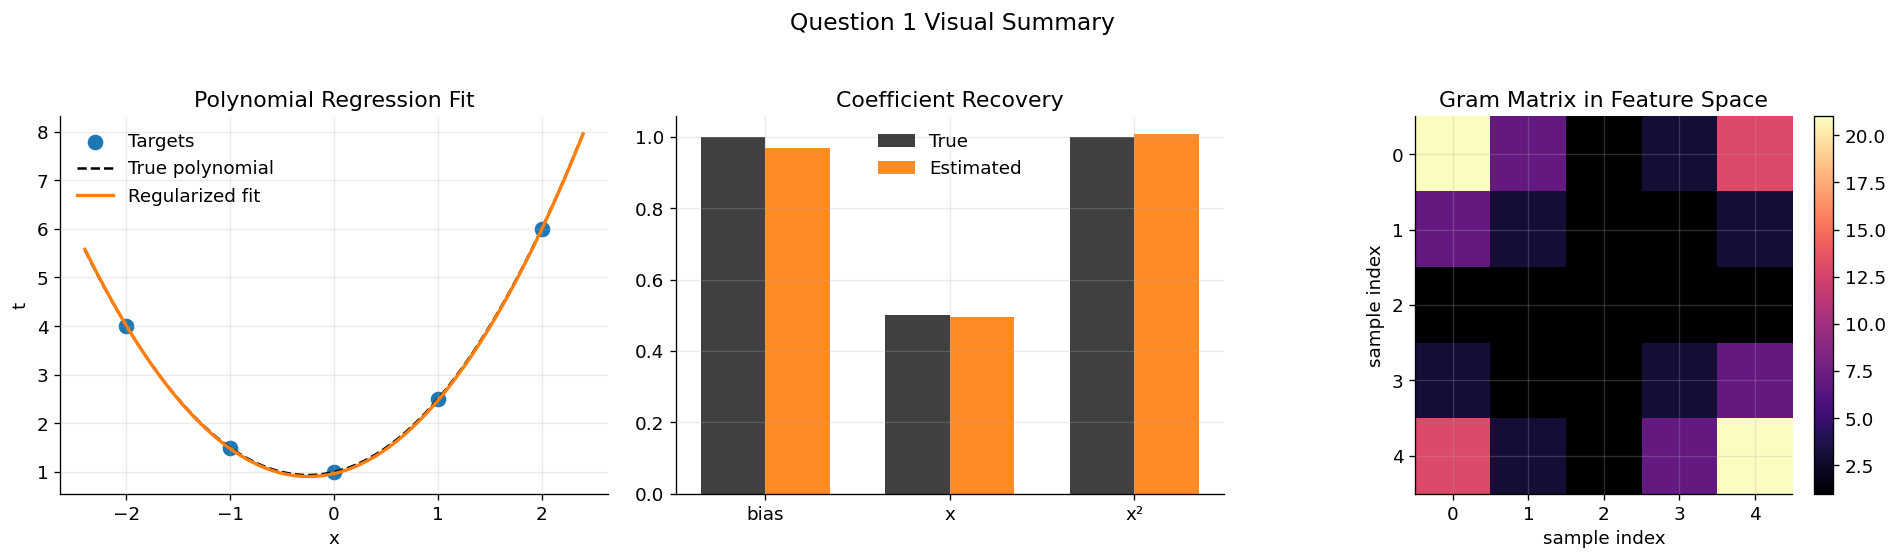

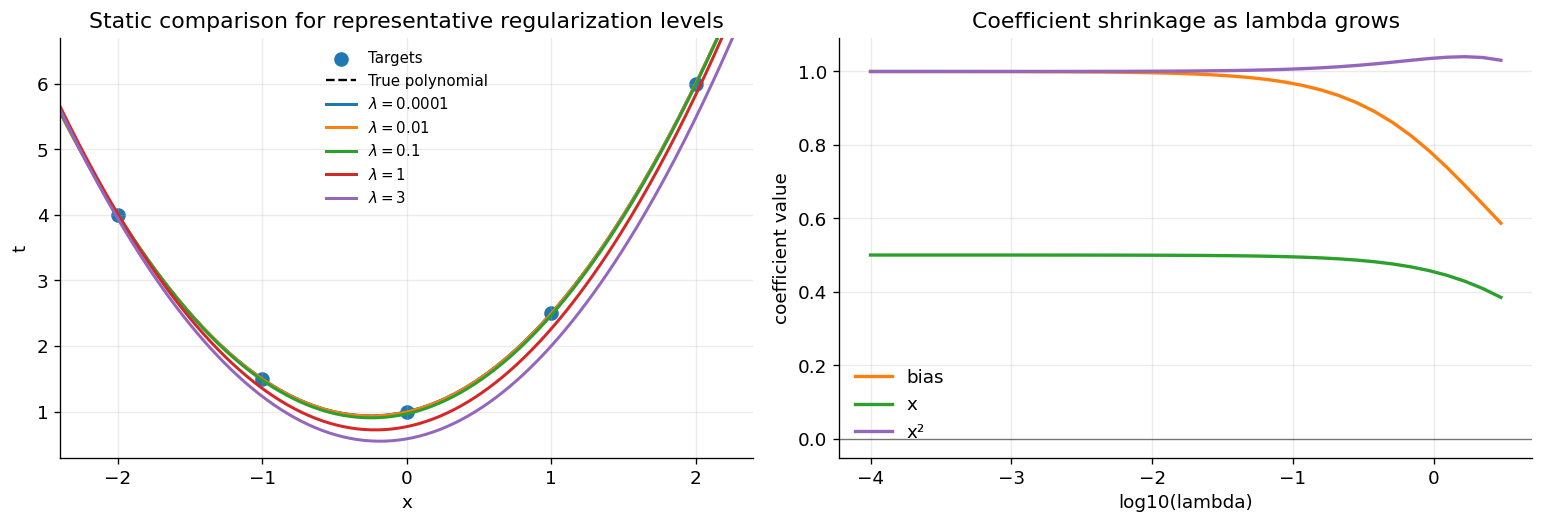

Key takeaway: stronger regularization smooths the fit and pulls all coefficients toward zero, while the kernel and primal solutions remain numerically identical.


In [20]:
# Bundle every numerical artifact needed for the Question 1 figures.
q1 = polynomial_regression_example(lambda_reg=0.1)
true_weights = np.array([1.0, 0.5, 1.0])
grid = np.linspace(-2.4, 2.4, 300)
phi_grid = build_polynomial_design_matrix(grid)
fit_grid = phi_grid @ q1["estimated_weights"]
true_grid = 1.0 + 0.5 * grid + grid ** 2

print("Concrete design matrix for x = [-2, -1, 0, 1, 2]:")
print(q1["design_matrix"])
print(f"max |w_hat - Phi^T alpha_hat| = {q1['max_abs_primal_dual_difference']:.3e}")
print("Interpretation: the primal solution and the dual reconstruction coincide up to machine precision.")

# First figure: data fit, coefficient recovery, and the feature-space Gram matrix.
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5), dpi=120)

axes[0].scatter(q1["x_samples"], q1["targets"], s=70, color="tab:blue", label="Targets")
axes[0].plot(grid, true_grid, color="black", linestyle="--", linewidth=1.5, label="True polynomial")
axes[0].plot(grid, fit_grid, color="tab:orange", linewidth=2.0, label="Regularized fit")
axes[0].set_title("Polynomial Regression Fit")
axes[0].set_xlabel("x")
axes[0].set_ylabel("t")
axes[0].legend(frameon=False)

bar_x = np.arange(3)
width = 0.35
axes[1].bar(bar_x - width / 2, true_weights, width=width, color="black", alpha=0.75, label="True")
axes[1].bar(bar_x + width / 2, q1["estimated_weights"], width=width, color="tab:orange", alpha=0.9, label="Estimated")
axes[1].set_xticks(bar_x)
axes[1].set_xticklabels(["bias", "x", "x^2"])
axes[1].set_title("Coefficient Recovery")
axes[1].legend(frameon=False)

im = axes[2].imshow(q1["kernel_matrix"], cmap="magma")
axes[2].set_title("Gram Matrix in Feature Space")
axes[2].set_xlabel("sample index")
axes[2].set_ylabel("sample index")
fig.colorbar(im, ax=axes[2], fraction=0.046, pad=0.04)

fig.suptitle("Question 1 Visual Summary", y=1.03, fontsize=14)
fig.tight_layout()
plt.show()

# Sweep lambda to show how ridge regularization shrinks the polynomial coefficients.
lambda_values = np.geomspace(1e-4, 3.0, 36)
weight_frames = []
for lambda_value in lambda_values:
    weights = solve_regularized_least_squares(q1["design_matrix"], q1["targets"], float(lambda_value))
    weight_frames.append(weights)
weight_frames = np.asarray(weight_frames)

selected_lambdas = [1e-4, 1e-2, 1e-1, 1.0, 3.0]

fig_reg, (ax_fit, ax_coef) = plt.subplots(1, 2, figsize=(13, 4.5), dpi=120)
ax_fit.scatter(q1["x_samples"], q1["targets"], s=60, color="tab:blue", label="Targets")
ax_fit.plot(grid, true_grid, color="black", linestyle="--", linewidth=1.4, label="True polynomial")
for lambda_value in selected_lambdas:
    weights = solve_regularized_least_squares(q1["design_matrix"], q1["targets"], float(lambda_value))
    ax_fit.plot(grid, phi_grid @ weights, linewidth=1.8, label=fr"$\lambda={lambda_value:g}$")
ax_fit.set_xlim(grid.min(), grid.max())
ax_fit.set_ylim(min(q1["targets"]) - 0.7, max(q1["targets"]) + 0.7)
ax_fit.set_xlabel("x")
ax_fit.set_ylabel("t")
ax_fit.set_title("Static comparison for representative regularization levels")
ax_fit.legend(frameon=False, fontsize=9)

log_lambda = np.log10(lambda_values)
coef_labels = ["bias", "x", "x^2"]
coef_colors = ["tab:orange", "tab:green", "tab:purple"]
for idx, (label, color) in enumerate(zip(coef_labels, coef_colors)):
    ax_coef.plot(log_lambda, weight_frames[:, idx], color=color, linewidth=2.0, label=label)
ax_coef.axhline(0.0, color="black", linewidth=0.8, alpha=0.5)
ax_coef.set_xlabel("log10(lambda)")
ax_coef.set_ylabel("coefficient value")
ax_coef.set_title("Coefficient shrinkage as lambda grows")
ax_coef.legend(frameon=False)

fig_reg.tight_layout()
plt.show()

print("Key takeaway: stronger regularization smooths the fit and pulls all coefficients toward zero, while the kernel and primal solutions remain numerically identical.")


### 1.3(b) SVD interpretation and kernel trick

Let the thin singular value decomposition of the coordinate design matrix be

$$
\Phi = U_r \Sigma_r V_r^{\top},
$$

where

$$
U_r \in \mathbb{R}^{N \times r},
\qquad
\Sigma_r \in \mathbb{R}^{r \times r},
\qquad
V_r \in \mathbb{R}^{M \times r}.
$$

Then

$$
\Phi^{\top}\Phi = V_r \Sigma_r^2 V_r^{\top},
\qquad
\Phi\Phi^{\top} = U_r \Sigma_r^2 U_r^{\top}.
$$

Hence both matrices share the same nonzero eigenvalues $\sigma_1^2,\dots,\sigma_r^2$. The matrix $\Phi^{\top}\Phi$ describes geometry in coordinates on the finite sample span, while $K = \Phi\Phi^{\top}$ describes geometry in sample space.

The second matrix is the Gram matrix

$$
K = \Phi\Phi^{\top} = TT^* \in \mathbb{R}^{N \times N},
\qquad
K_{ij} = (\Phi\Phi^{\top})_{ij} = \langle \phi(x_i), \phi(x_j) \rangle_{\mathcal{H}}.
$$

Thus $\Phi^{\top}\Phi$ is the primal matrix in coordinates on $\mathcal{H}_N$, whereas $K$ is the sample-space matrix built from pairwise feature-space inner products. In an RKHS, the same identity is written as $K_{ij}=k(x_i,x_j)$ even when $\phi(x)$ is not expanded explicitly.

Since all pairwise feature-space inner products are contained in $K$, the geometry of the transformed data can be recovered without explicitly constructing coordinates for $\phi(x)$. Therefore, whenever only inner products between transformed samples are needed, one may replace $\langle \phi(x_i), \phi(x_j) \rangle_{\mathcal{H}}$ by $k(x_i,x_j)$, which is the essence of the kernel trick.

Now let

$$
\mathcal{H}_N = \operatorname{span}\{\phi(x_1),\dots,\phi(x_N)\}.
$$

For any $w \in \mathcal{H}$, write the orthogonal decomposition

$$
w = w_{\parallel} + w_{\perp},
\qquad
w_{\parallel} \in \mathcal{H}_N,
\quad
w_{\perp} \perp \mathcal{H}_N.
$$

Since $\phi(x_n) \in \mathcal{H}_N$, one has

$$
\langle w_{\perp}, \phi(x_n) \rangle_{\mathcal{H}} = 0
\qquad
\forall n.
$$

Therefore the data-fit term depends only on $w_{\parallel}$, whereas

$$
\lVert w \rVert_{\mathcal{H}}^2
= \lVert w_{\parallel} \rVert_{\mathcal{H}}^2 + \lVert w_{\perp} \rVert_{\mathcal{H}}^2
\ge \lVert w_{\parallel} \rVert_{\mathcal{H}}^2.
$$

Hence every minimizer belongs to $\mathcal{H}_N$, and there exist coefficients $\alpha_1,\dots,\alpha_N$ such that

$$
\widehat w = \sum_{n=1}^N \alpha_n \, \phi(x_n) = T^* \alpha.
$$

Using the operator identity

$$
(T^*T + \lambda I_{\mathcal{H}})^{-1} T^*
= T^* (TT^* + \lambda I_N)^{-1},
$$

the abstract optimality condition from Question 1.2 yields

$$
\widehat w
= T^*(TT^* + \lambda I_N)^{-1} t
= T^*(K + \lambda I_N)^{-1} t.
$$

Therefore,

$$
\alpha = (K + \lambda I_N)^{-1} t,
\qquad
\widehat f(x) = \langle \widehat w, \phi(x) \rangle_{\mathcal{H}}
= \sum_{n=1}^N \alpha_n \, k(x_n,x).
$$

Thus the coefficient representation is derived for the estimator in function space, not guessed from algebraic analogy.


## 2. RKHS, Mean Embeddings, and Discrepancy Between Distributions

### 2.1 Empirical mean embedding, dimensions, and kernel interpretation

Let $k : \mathcal{X} \times \mathcal{X} \to \mathbb{R}$ be a positive-definite kernel with associated RKHS $\mathcal{H}_k$. The original observations may still lie in $\mathbb{R}^P$, but after the kernel map they are treated as elements $\phi(x_n) \in \mathcal{H}_k$.

For a finite sample $\{x_n\}_{n=1}^N$, the empirical mean embedding is

$$
\widehat{\mu}_X = \frac{1}{N}\sum_{n=1}^N \phi(x_n)
= \frac{1}{N}\sum_{n=1}^N k(x_n,\cdot)
\in \mathcal{H}_k.
$$

At a query point $z \in \mathcal{X}$,

$$
\bigl\langle \widehat{\mu}_X, k(z,\cdot) \bigr\rangle_{\mathcal{H}_k}
= \frac{1}{N}\sum_{n=1}^N k(x_n,z).
$$

Define the kernel-evaluation vector

$$
k_z = [k(x_1,z),\dots,k(x_N,z)]^{\top} \in \mathbb{R}^{N}.
$$

Then the same evaluation can be written in sample-space form as

$$
\bigl\langle \widehat{\mu}_X, k(z,\cdot) \bigr\rangle_{\mathcal{H}_k}
= \frac{1}{N}\mathbf{1}_N^{\top} k_z.
$$

In the associated matrix formulation, kernel evaluations among the $N$ samples are collected in a Gram matrix $K \in \mathbb{R}^{N \times N}$ with entries $K_{ij}=k(x_i,x_j)$.

Two important examples are:

- **Linear kernel:** $k(x_i,x_j)=x_i^{\top}x_j$. Then the feature map can be identified with the original vector, so the mean embedding coincides with the Euclidean sample mean in $\mathbb{R}^P$.
- **Gaussian RBF kernel:** $k(x_i,x_j)=\exp(-\gamma\lVert x_i-x_j \rVert_2^2)$. Then the embedding is nonlinear, typically infinite-dimensional, and geometry is encoded through pairwise similarities rather than explicit coordinates in the original space.

So the linear kernel preserves direct Euclidean interpretation in the original coordinates, whereas the RBF kernel captures nonlinear local similarity through the RKHS.


### 2.2 Raw, centered, and standardized moments in the original and kernel-induced spaces

In the original space, for a scalar random variable $X$ (or componentwise for a vector in $\mathbb{R}^P$), the standard distinctions are:

- **Raw moment of order $r$:** $\mathbb{E}[X^r]$.
- **Centered moment of order $r$:** $\mathbb{E}[(X-\mu)^r]$, where $\mu = \mathbb{E}[X]$.
- **Standardized moment of order $r$:** $\mathbb{E}[((X-\mu)/\sigma)^r]$, where $\sigma^2 = \operatorname{Var}(X)$.

For vector-valued data, the second raw moment becomes $\mathbb{E}[XX^{\top}]$, while the second centered moment is the covariance matrix $\mathbb{E}[(X-\mu)(X-\mu)^{\top}]$.

In feature space or RKHS, the same ideas become operator-valued:

$$
\mu_P = \mathbb{E}[\phi(X)] = \mathbb{E}[k(X,\cdot)]
$$

is the analogue of the first raw moment, and

$$
M_P = \mathbb{E}[\phi(X) \otimes \phi(X)]
$$

is the second raw moment operator. After centering,

$$
C_P = \mathbb{E}\big[(\phi(X)-\mu_P) \otimes (\phi(X)-\mu_P)\big]
$$

is the RKHS covariance operator, i.e. the analogue of the second centered moment.

Thus, in an RKHS, the first raw moment is an element of $\mathcal{H}_k$, while the second raw and centered moments are naturally linear operators on $\mathcal{H}_k$, not merely scalars. This is the precise analogue of the passage from scalar variance to covariance matrices in multivariate Euclidean spaces.

Unlike raw and centered moments, a standardized moment in an RKHS is not canonical, because there is no distinguished scalar variance by which all directions can be normalized simultaneously. Any normalization must be defined relative to the covariance operator $C_P$, for example through a regularized whitening operator $(C_P + \varepsilon I)^{-1/2}$. Consequently, standardized moments in kernel spaces are operator-dependent constructions rather than unique intrinsic objects.

In the sample matrix formulation, centering is encoded by

$$
H = I_N - \frac{1}{N}\mathbf{1}_N\mathbf{1}_N^{\top},
\qquad
K_c = H K H,
$$

so the centered RKHS geometry is handled without constructing explicit feature coordinates.


### 2.3 From the RKHS norm to the empirical MMD matrix formula

For two distributions $P$ and $Q$, let

$$
\mu_P = \mathbb{E}[\phi(X)],
\qquad
\mu_Q = \mathbb{E}[\phi(Y)].
$$

The squared maximum mean discrepancy is the RKHS distance between these two mean embeddings:

$$
\operatorname{MMD}^2(P,Q)
= \lVert \mu_P - \mu_Q \rVert_{\mathcal{H}_k}^2.
$$

Expand the norm:

$$
\lVert \mu_P - \mu_Q \rVert_{\mathcal{H}_k}^2
= \langle \mu_P, \mu_P \rangle_{\mathcal{H}_k}
+ \langle \mu_Q, \mu_Q \rangle_{\mathcal{H}_k}
- 2\langle \mu_P, \mu_Q \rangle_{\mathcal{H}_k}.
$$

Using the reproducing property,

$$
\langle \mu_P, \mu_P \rangle_{\mathcal{H}_k} = \mathbb{E}[k(X,X')],
\qquad
\langle \mu_Q, \mu_Q \rangle_{\mathcal{H}_k} = \mathbb{E}[k(Y,Y')],
$$

$$
\langle \mu_P, \mu_Q \rangle_{\mathcal{H}_k} = \mathbb{E}[k(X,Y)],
$$

so

$$
\operatorname{MMD}^2(P,Q)
= \mathbb{E}[k(X,X')] + \mathbb{E}[k(Y,Y')] - 2\mathbb{E}[k(X,Y)].
$$

For finite samples $X_m = \{x_i\}_{i=1}^m$ and $Y_n = \{y_j\}_{j=1}^n$, define

$$
K_{XX} \in \mathbb{R}^{m \times m},
\qquad
K_{YY} \in \mathbb{R}^{n \times n},
\qquad
K_{XY} \in \mathbb{R}^{m \times n},
$$

with

$$
\mathbf{1}_m \in \mathbb{R}^{m},
\qquad
\mathbf{1}_n \in \mathbb{R}^{n}.
$$

Then the biased empirical estimator used in the code below is

$$
\widehat{\operatorname{MMD}}_{\mathrm{b}}^2
= \frac{1}{m^2}\mathbf{1}_m^{\top} K_{XX} \mathbf{1}_m
+ \frac{1}{n^2}\mathbf{1}_n^{\top} K_{YY} \mathbf{1}_n
- \frac{2}{mn}\mathbf{1}_m^{\top} K_{XY} \mathbf{1}_n.
$$

For completeness, the unbiased estimator removes the diagonal terms:

$$
\widehat{\operatorname{MMD}}_{\mathrm{u}}^2
= \frac{1}{m(m-1)}\sum_{i \ne i'} k(x_i,x_{i'})
+ \frac{1}{n(n-1)}\sum_{j \ne j'} k(y_j,y_{j'})
- \frac{2}{mn}\sum_{i=1}^{m}\sum_{j=1}^{n} k(x_i,y_j).
$$

It is called biased because it keeps the diagonal self-similarity terms of $K_{XX}$ and $K_{YY}$. In this notebook we use the biased estimator because it admits the compact matrix expression above and is sufficient for the intended empirical comparison.

The derivation of the empirical MMD formula is complete independently of any dataset. The MNIST experiment is included only as a numerical illustration of the derived estimator; its exact ranking of class pairs is contingent on the sampled subset, the bandwidth choice, the estimator variant, and the availability of the local dataset files.

The following outputs visualize that estimator through a geometric mean-embedding demo and an MNIST class-discrepancy heatmap.


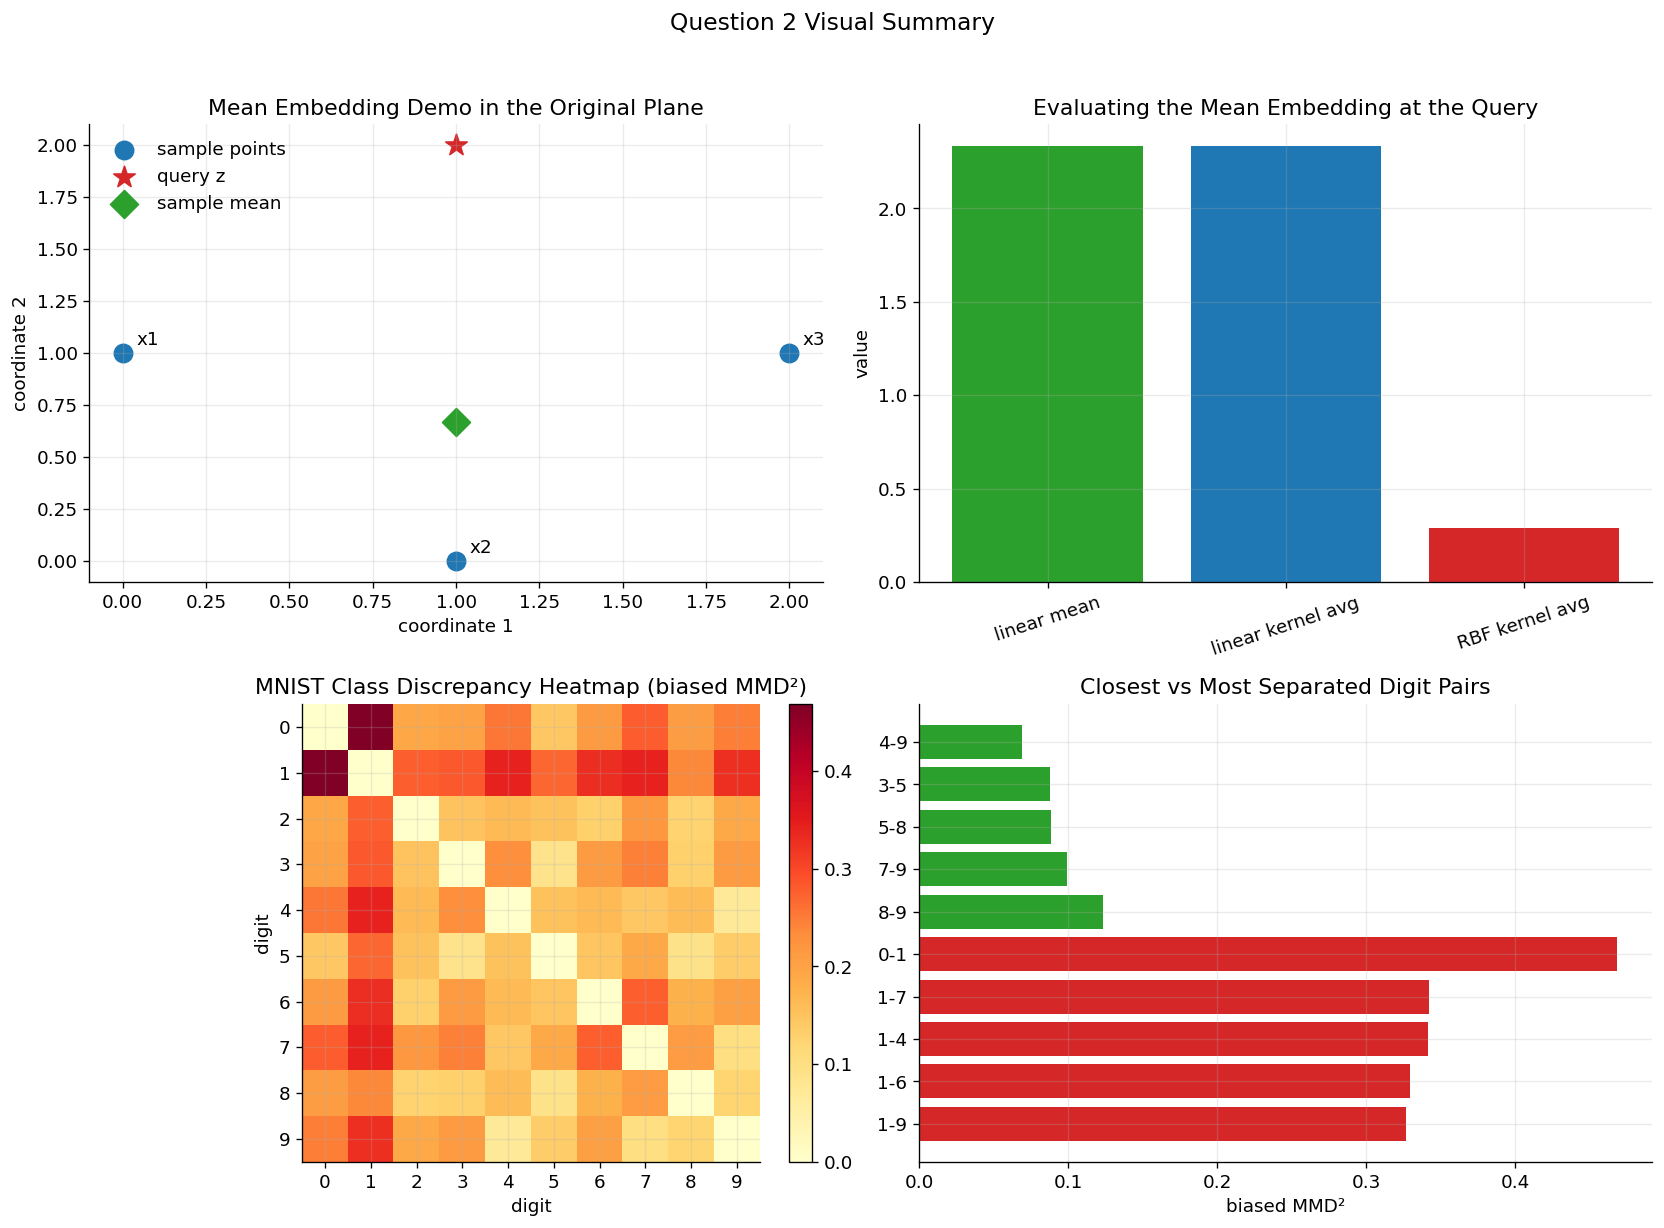

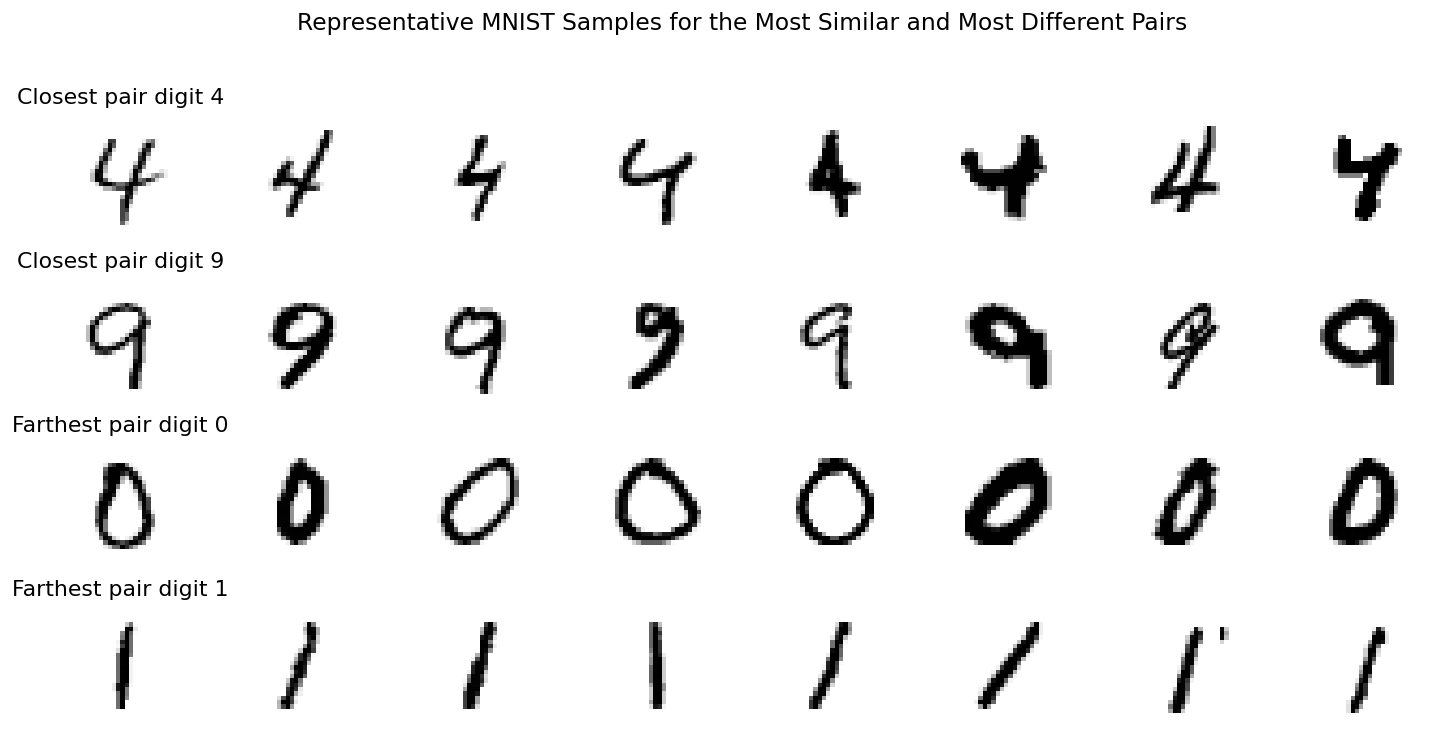

Closest pair: 4 vs 9 with MMD² = 0.0689
Most separated pair: 0 vs 1 with MMD² = 0.4687
Key takeaway: the heatmap exposes class-level structure immediately, while the digit strips show why some pairs look geometrically close and others do not.


In [21]:
# Build the toy finite-sample example and the full MNIST discrepancy experiment.
embedding = mean_embedding_demo()
q2 = mnist_mmd_full(samples_per_class=100, seed=2026)
smallest = q2['pair_scores'][:5]
largest = q2['pair_scores'][-5:][::-1]
closest_pair = smallest[0][:2]
farthest_pair = largest[0][:2]

# First figure: embedding intuition, full MMD heatmap, and extreme pair comparison.
fig, axes = plt.subplots(2, 2, figsize=(14, 10), dpi=120)

samples = embedding['samples']
query = embedding['query']
axes[0, 0].scatter(samples[:, 0], samples[:, 1], s=120, color='tab:blue', label='sample points')
for idx, point in enumerate(samples):
    axes[0, 0].annotate(f'x{idx+1}', point + np.array([0.04, 0.04]))
axes[0, 0].scatter([query[0]], [query[1]], s=180, color='tab:red', marker='*', label='query z')
axes[0, 0].scatter([embedding['linear_sample_mean'][0]], [embedding['linear_sample_mean'][1]], s=140, color='tab:green', marker='D', label='sample mean')
axes[0, 0].set_title('Mean Embedding Demo in the Original Plane')
axes[0, 0].set_xlabel('coordinate 1')
axes[0, 0].set_ylabel('coordinate 2')
axes[0, 0].legend(frameon=False, loc='upper left')

bar_labels = ['linear mean', 'linear kernel avg', 'RBF kernel avg']
bar_values = [embedding['linear_eval_via_mean'], embedding['linear_eval_direct_kernel_average'], embedding['rbf_eval_at_query']]
bar_colors = ['tab:green', 'tab:blue', 'tab:red']
axes[0, 1].bar(bar_labels, bar_values, color=bar_colors)
axes[0, 1].set_title('Evaluating the Mean Embedding at the Query')
axes[0, 1].set_ylabel('value')
axes[0, 1].tick_params(axis='x', rotation=18)

heat = axes[1, 0].imshow(q2['mmd_matrix'], cmap='YlOrRd')
axes[1, 0].set_title('MNIST Class Discrepancy Heatmap (biased MMD^2)')
axes[1, 0].set_xlabel('digit')
axes[1, 0].set_ylabel('digit')
axes[1, 0].set_xticks(range(10))
axes[1, 0].set_yticks(range(10))
fig.colorbar(heat, ax=axes[1, 0], fraction=0.046, pad=0.04)

pair_labels = [f'{a}-{b}' for a, b, _ in smallest] + [f'{a}-{b}' for a, b, _ in largest]
pair_values = [score for _, _, score in smallest] + [score for _, _, score in largest]
pair_colors = ['tab:green'] * len(smallest) + ['tab:red'] * len(largest)
axes[1, 1].barh(pair_labels, pair_values, color=pair_colors)
axes[1, 1].set_title('Closest vs Most Separated Digit Pairs')
axes[1, 1].set_xlabel('biased MMD^2')
axes[1, 1].invert_yaxis()

fig.suptitle('Question 2 Visual Summary', y=1.02, fontsize=14)
fig.tight_layout()
plt.show()

# Second figure: inspect actual digits from the closest and farthest pairs.
fig_digits, axes_digits = plt.subplots(4, 8, figsize=(12, 6), dpi=120)
for row, digit in enumerate(closest_pair):
    for col in range(4):
        axes_digits[row, col].imshow(q2['balanced'][digit][col].reshape(28, 28), cmap='gray_r')
        axes_digits[row, col].axis('off')
    axes_digits[row, 0].set_title(f'Closest pair digit {digit}')
for row, digit in enumerate(farthest_pair, start=2):
    for col in range(4):
        axes_digits[row, col].imshow(q2['balanced'][digit][col].reshape(28, 28), cmap='gray_r')
        axes_digits[row, col].axis('off')
    axes_digits[row, 0].set_title(f'Farthest pair digit {digit}')
for row in range(4):
    for col in range(4, 8):
        digit = closest_pair[row] if row < 2 else farthest_pair[row - 2]
        axes_digits[row, col].imshow(q2['balanced'][digit][col].reshape(28, 28), cmap='gray_r')
        axes_digits[row, col].axis('off')
fig_digits.suptitle('Representative MNIST Samples for the Most Similar and Most Different Pairs', y=1.02, fontsize=14)
fig_digits.tight_layout()
plt.show()

print(f"Closest pair: {closest_pair[0]} vs {closest_pair[1]} with MMD^2 = {smallest[0][2]:.4f}")
print(f"Most separated pair: {farthest_pair[0]} vs {farthest_pair[1]} with MMD^2 = {largest[0][2]:.4f}")
print('Key takeaway: the heatmap exposes class-level structure immediately, while the digit strips show why some pairs look geometrically close and others do not.')


## 3. Matrix Form of Kernels and Induced Geometry

### 3.1 Distance matrix in the original space

Let $X \in \mathbb{R}^{N \times P}$ be the data matrix whose rows are the samples $x_1,\dots,x_N \in \mathbb{R}^P$. For two samples $x_i$ and $x_j$,

$$
\lVert x_i - x_j \rVert_2^2
= (x_i - x_j)^{\top}(x_i - x_j)
= x_i^{\top}x_i + x_j^{\top}x_j - 2x_i^{\top}x_j.
$$

If we define the vector of squared norms by

$$
s = \begin{bmatrix}
\lVert x_1 \rVert_2^2 \\
\vdots \\
\lVert x_N \rVert_2^2
\end{bmatrix}
\in \mathbb{R}^{N},
$$

then the full matrix of squared distances is

$$
D = s\mathbf{1}^{\top} + \mathbf{1}s^{\top} - 2XX^{\top},
\qquad
\mathbf{1} \in \mathbb{R}^{N},
\qquad
D \in \mathbb{R}^{N \times N}.
$$

Indeed, the $(i,j)$-th entry of $s\mathbf{1}^{\top} + \mathbf{1}s^{\top} - 2XX^{\top}$ is

$$
s_i + s_j - 2x_i^{\top}x_j
= \lVert x_i \rVert_2^2 + \lVert x_j \rVert_2^2 - 2x_i^{\top}x_j
= \lVert x_i - x_j \rVert_2^2.
$$

This part is entirely in the original Euclidean input space $\mathbb{R}^P$.

### 3.2 Gaussian kernel matrix and positive semidefiniteness

For the Gaussian kernel matrix

$$
K_{ij} = \exp\bigl(-\gamma \lVert x_i - x_j \rVert_2^2\bigr),
$$

the diagonal entries satisfy

$$
K_{ii} = \exp(0) = 1,
$$

so every mapped sample has unit norm in feature space. Passing to the RKHS viewpoint,

$$
K_{ij} = \langle \phi(x_i), \phi(x_j) \rangle_{\mathcal{H}_k}.
$$

Since $K_{ii} = k(x_i, x_i) = 1$, every transformed sample satisfies

$$
\lVert \phi(x_i) \rVert_{\mathcal{H}_k}^2
= \langle \phi(x_i), \phi(x_i) \rangle_{\mathcal{H}_k}
= 1.
$$

Thus all transformed samples lie on the unit sphere of the induced feature space, and variation among kernel values is entirely due to pairwise inner products between those unit-norm feature vectors.

Symmetry follows from $k(x_i,x_j)=k(x_j,x_i)$. Positive semidefiniteness follows analytically because, for every $c \in \mathbb{R}^{N}$,

$$
c^{\top} K c
= \sum_{i=1}^N \sum_{j=1}^N c_i c_j k(x_i,x_j)
= \left\lVert \sum_{i=1}^N c_i \phi(x_i) \right\rVert_{\mathcal{H}_k}^2
\ge 0.
$$

Therefore $K$ is a symmetric positive semidefinite Gram matrix by construction. The numerical eigenvalue plot below is only an illustration of this theorem, not the proof itself.


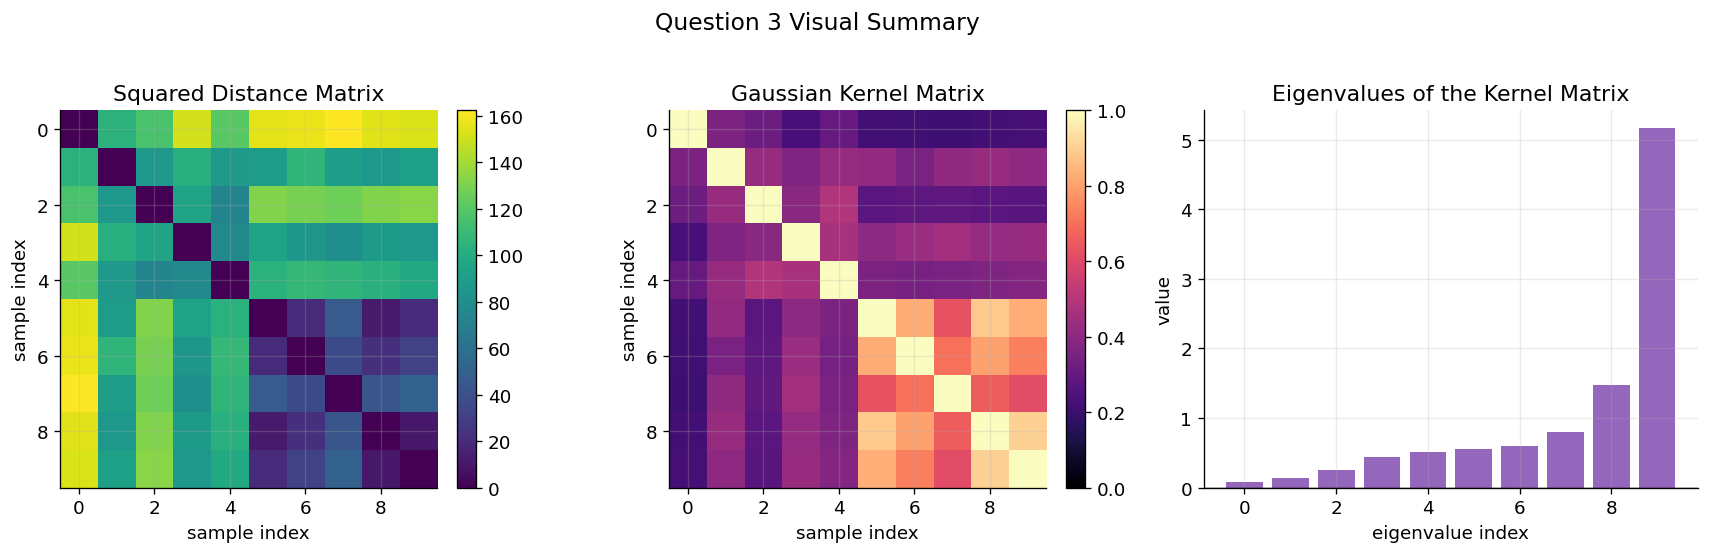

Max distance-formula error: 5.68e-14
Max kernel diagonal error from 1: 5.55e-16
Max symmetry error: 0.00e+00
Minimum eigenvalue: 0.0777
Key takeaway: the distance heatmap turns into a symmetric positive-semidefinite Gram matrix under the Gaussian kernel, with a constant diagonal exactly as the theory predicts.


In [22]:
# Reuse the kernel scale from Question 2 to inspect the geometry induced by the Gaussian kernel.
geom = kernel_geometry_bundle(gamma=q2['gamma'], seed=2026)

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5), dpi=120)

# Compare the original-space distance geometry with the induced Gram geometry.
dist_im = axes[0].imshow(geom['distances'], cmap='viridis')
axes[0].set_title('Squared Distance Matrix')
axes[0].set_xlabel('sample index')
axes[0].set_ylabel('sample index')
fig.colorbar(dist_im, ax=axes[0], fraction=0.046, pad=0.04)

ker_im = axes[1].imshow(geom['kernel'], cmap='magma', vmin=0.0, vmax=1.0)
axes[1].set_title('Gaussian Kernel Matrix')
axes[1].set_xlabel('sample index')
axes[1].set_ylabel('sample index')
fig.colorbar(ker_im, ax=axes[1], fraction=0.046, pad=0.04)

axes[2].bar(np.arange(len(geom['eigenvalues'])), geom['eigenvalues'], color='tab:purple')
axes[2].axhline(0.0, color='black', linewidth=0.8)
axes[2].set_title('Eigenvalues of the Kernel Matrix')
axes[2].set_xlabel('eigenvalue index')
axes[2].set_ylabel('value')

fig.suptitle('Question 3 Visual Summary', y=1.02, fontsize=14)
fig.tight_layout()
plt.show()

print(f"Max distance-formula error: {geom['distance_error']:.2e}")
print(f"Max kernel diagonal error from 1: {geom['diag_error']:.2e}")
print(f"Max symmetry error: {geom['symmetry_error']:.2e}")
print(f"Minimum eigenvalue: {geom['eigenvalues'].min():.4f}")
print('Key takeaway: the distance heatmap turns into a symmetric positive-semidefinite Gram matrix under the Gaussian kernel, with a constant diagonal exactly as the theory predicts.')
